# ICU Sepsis Early Prediction System
## Model Comparison

In this notebook we compare multiple machine learning models on the processed ICU sepsis dataset.

### Models
- Logistic Regression
- Random Forest
- XGBoost
- LightGBM


### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC
- Confusion Matrix

The best performing model will be selected for deployment.

In [1]:
# ============================================================
# Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import joblib

In [2]:
# ============================================================
# Load Processed Dataset
# ============================================================

train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

print("Training Shape :", train_df.shape)
print("Testing Shape  :", test_df.shape)

train_df.head()

Training Shape : (1241213, 55)
Testing Shape  : (310997, 55)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,Age,SepsisLabel,ICULOS,...,Resp_RollingMax_3,HR_RollingMin_3,O2Sat_RollingMin_3,Temp_RollingMin_3,SBP_RollingMin_3,MAP_RollingMin_3,DBP_RollingMin_3,Resp_RollingMin_3,PulsePressure,ShockIndex
0,83.5,98.0,37.0,121.0,80.00,62.0,18.0,83.14,0,1,...,18.0,83.5,98.0,37.0,121.0,80.00,62.0,18.0,59.0,0.690083
1,97.0,95.0,37.0,98.0,75.33,62.0,19.0,83.14,0,2,...,19.0,83.5,95.0,37.0,98.0,75.33,62.0,18.0,36.0,0.989796
2,89.0,99.0,37.0,122.0,86.00,62.0,22.0,83.14,0,3,...,22.0,83.5,95.0,37.0,98.0,75.33,62.0,18.0,60.0,0.729508
3,90.0,95.0,37.0,121.0,80.00,62.0,30.0,83.14,0,4,...,30.0,89.0,95.0,37.0,98.0,75.33,62.0,19.0,59.0,0.743802
4,103.0,88.5,37.0,122.0,91.33,62.0,24.5,83.14,0,5,...,30.0,89.0,88.5,37.0,121.0,80.00,62.0,22.0,60.0,0.844262


In [3]:
# ============================================================
# Separate Features and Target
# ============================================================

X_train = train_df.drop(columns=["SepsisLabel", "Patient_ID"])
y_train = train_df["SepsisLabel"]

X_test = test_df.drop(columns=["SepsisLabel", "Patient_ID"])
y_test = test_df["SepsisLabel"]

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print()

print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

X_train : (1241213, 53)
y_train : (1241213,)

X_test  : (310997, 53)
y_test  : (310997,)


In [4]:
# ============================================================
# Model Evaluation Function
# ============================================================

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")   

    print("\nConfusion Matrix")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay(cm).plot()
    plt.show()
    
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }    

In [5]:
# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Complete!")

print()

print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

Feature Scaling Complete!

Scaled Training Shape : (1241213, 53)
Scaled Testing Shape  : (310997, 53)


In [6]:
# ============================================================
# Logistic Regression
# ============================================================

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression Trained Succesfully!")

Logistic Regression Trained Succesfully!


Accuracy : 0.7669
Precision: 0.0426
Recall   : 0.5962
F1 Score : 0.0795
ROC-AUC  : 0.7324
PR-AUC   : 0.0719

Confusion Matrix
[[235388  70362]
 [  2119   3128]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.77      0.87    305750
           1       0.04      0.60      0.08      5247

    accuracy                           0.77    310997
   macro avg       0.52      0.68      0.47    310997
weighted avg       0.98      0.77      0.85    310997



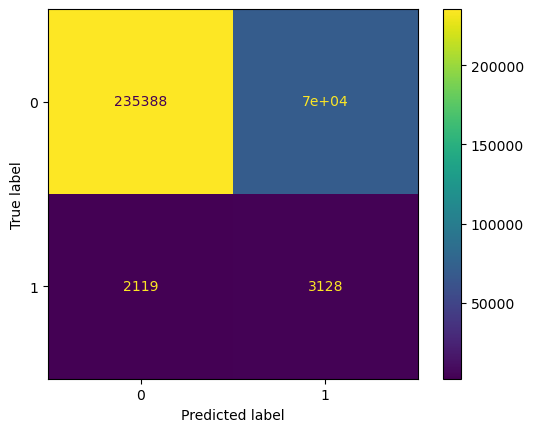

In [7]:
# ============================================================
# Evaluate Logistic Regression
# ============================================================

logistic_results = evaluate_model(
    logistic_model,
    X_test_scaled,
    y_test
)

In [8]:
# ============================================================
# Store Model Results
# ============================================================

results = {}

results["Logistic Regression"] = logistic_results

In [9]:
# ============================================================
# Random Forest Classifier
# ============================================================

random_forest = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

print("Random Forest Trained Successfully!")

Random Forest Trained Successfully!


Accuracy : 0.9807
Precision: 0.0469
Recall   : 0.0074
F1 Score : 0.0128
ROC-AUC  : 0.7086
PR-AUC   : 0.0452

Confusion Matrix
[[304958    792]
 [  5208     39]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    305750
           1       0.05      0.01      0.01      5247

    accuracy                           0.98    310997
   macro avg       0.52      0.50      0.50    310997
weighted avg       0.97      0.98      0.97    310997



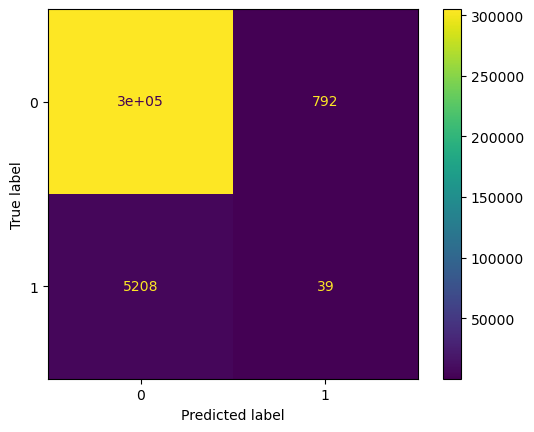

In [10]:
# ============================================================
# Evaluate Random Forest
# ============================================================

rf_results = evaluate_model(
    random_forest,
    X_test,
    y_test
)

In [11]:
results["RandomForest"] = rf_results

In [12]:
# ============================================================
# XGBoost Classifier
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

print("XGBoost Trained Successfully!")

XGBoost Trained Successfully!


Accuracy : 0.9829
Precision: 0.3368
Recall   : 0.0122
F1 Score : 0.0235
ROC-AUC  : 0.7918
PR-AUC   : 0.0931

Confusion Matrix
[[305624    126]
 [  5183     64]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    305750
           1       0.34      0.01      0.02      5247

    accuracy                           0.98    310997
   macro avg       0.66      0.51      0.51    310997
weighted avg       0.97      0.98      0.98    310997



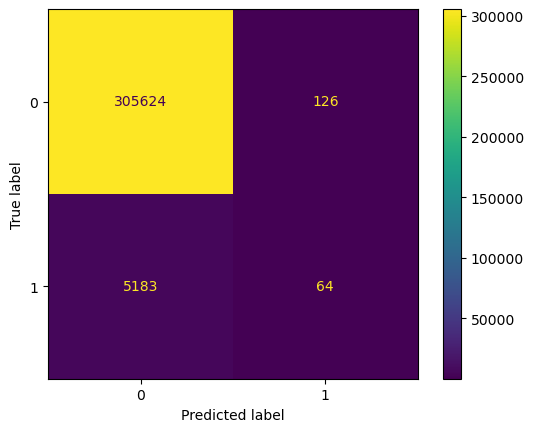

In [13]:
# ============================================================
# Evaluate XGBoost
# ============================================================

xgb_results = evaluate_model(
    xgb_model,
    X_test,
    y_test
)

In [14]:
results["XGBoost"] = xgb_results

In [15]:
# ============================================================
# LightGBM Classifier
# ============================================================

lightgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
)

lightgbm_model.fit(X_train, y_train)

print("LightGBM Trained Successfully!")

[LightGBM] [Info] Number of positive: 22669, number of negative: 1218544
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11062
[LightGBM] [Info] Number of data points in the train set: 1241213, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018264 -> initscore=-3.984414
[LightGBM] [Info] Start training from score -3.984414
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Trained Successfully!


Accuracy : 0.9825
Precision: 0.2171
Recall   : 0.0135
F1 Score : 0.0255
ROC-AUC  : 0.7908
PR-AUC   : 0.0899

Confusion Matrix
[[305494    256]
 [  5176     71]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    305750
           1       0.22      0.01      0.03      5247

    accuracy                           0.98    310997
   macro avg       0.60      0.51      0.51    310997
weighted avg       0.97      0.98      0.97    310997



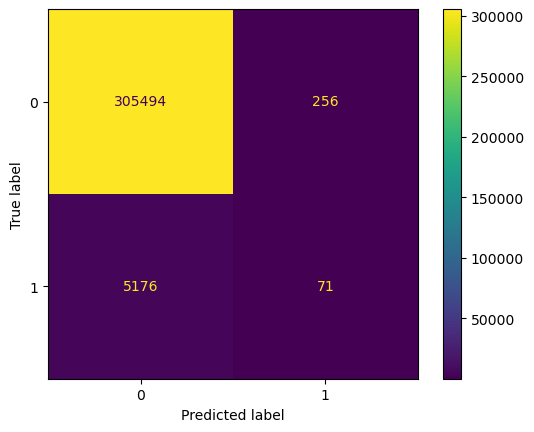

In [16]:
# ============================================================
# Evaluate LightGBM
# ============================================================

lightgbm_results = evaluate_model(
    lightgbm_model,
    X_test,
    y_test
)

In [17]:
results["LightGBM"] = lightgbm_results

In [18]:
results_df = pd.DataFrame(results).T

results_df = results_df[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]]

results_df.sort_values(by="ROC-AUC", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
XGBoost,0.982929,0.336842,0.012197,0.023542,0.791821,0.093084
LightGBM,0.982534,0.217125,0.013532,0.025475,0.790827,0.089938
Logistic Regression,0.766940,0.042564,0.596150,0.079454,0.732385,0.071854
RandomForest,0.980707,0.046931,0.007433,0.012833,0.708561,0.045215
